In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

In [3]:
a = load_iris
b = sns.load_dataset("iris")

In [6]:
x = b.iloc[:,:-1]
y = load_iris().target

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=40)

In [22]:
model = DecisionTreeClassifier(criterion='gini',random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

[Text(0.3076923076923077, 0.9285714285714286, 'petal length (cm) <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]\nclass = versicolor'),
 Text(0.23076923076923078, 0.7857142857142857, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]\nclass = setosa'),
 Text(0.2692307692307693, 0.8571428571428572, 'True  '),
 Text(0.38461538461538464, 0.7857142857142857, 'petal length (cm) <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]\nclass = versicolor'),
 Text(0.34615384615384615, 0.8571428571428572, '  False'),
 Text(0.15384615384615385, 0.6428571428571429, 'petal width (cm) <= 1.65\ngini = 0.053\nsamples = 37\nvalue = [0, 36, 1]\nclass = versicolor'),
 Text(0.07692307692307693, 0.5, 'gini = 0.0\nsamples = 36\nvalue = [0, 36, 0]\nclass = versicolor'),
 Text(0.23076923076923078, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]\nclass = virginica'),
 Text(0.6153846153846154, 0.6428571428571429, 'petal width (cm) <= 1.75\ngini = 0.206\nsamples = 43\nvalue = [0, 5, 38]\nclass = virginica

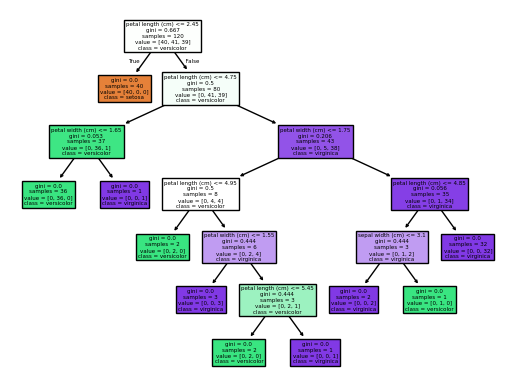

In [12]:
from sklearn.tree import plot_tree
iris = load_iris()
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
)

In [23]:
from sklearn.metrics import accuracy_score

tree_gini= DecisionTreeClassifier(criterion='gini',random_state=40)
tree_gini.fit(x_train,y_train)

gini_predictions= tree_gini.predict(x_test)
gini_score= accuracy_score(y_test,gini_predictions)


In [24]:
tree_entropy= DecisionTreeClassifier(criterion='entropy',random_state=22)
tree_entropy.fit(x_train,y_train)

entropy_predictions= tree_entropy.predict(x_test)
entropy_score= accuracy_score(y_test,entropy_predictions)

In [25]:
print("Gini Accuracy", gini_score)
print("Entropy accuracy", entropy_score)

Gini Accuracy 1.0
Entropy accuracy 1.0


QUESTION 3

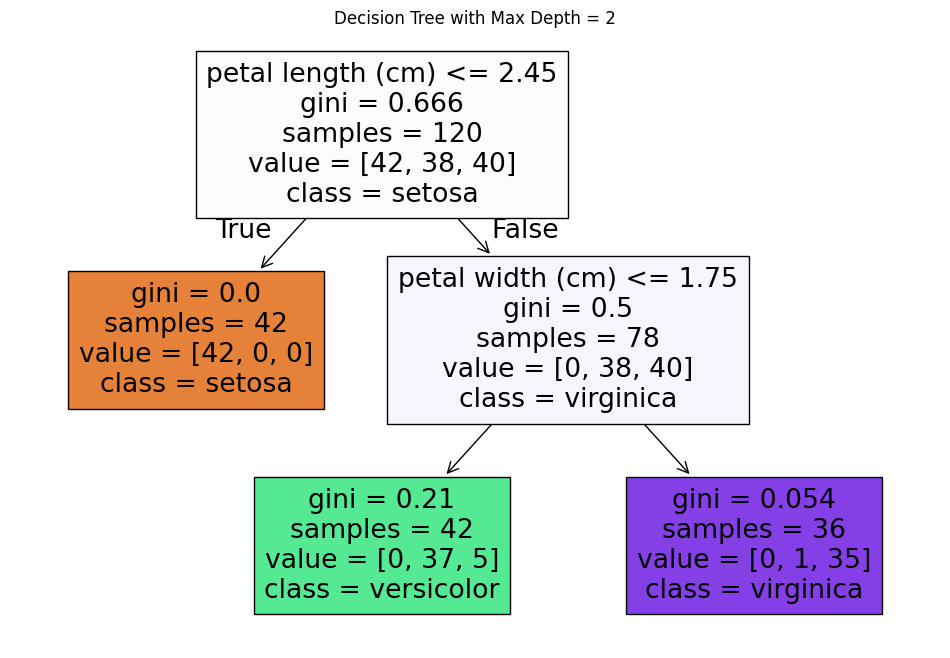

In [27]:
tree_depth2 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=2,
    random_state=42
)

tree_depth2.fit(x_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(
    tree_depth2,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)
plt.title("Decision Tree with Max Depth = 2")
plt.show()

QUESTION 4

In [28]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": iris.feature_names,
    "Importance": tree_gini.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

             Feature  Importance
2  petal length (cm)    0.576754
3   petal width (cm)    0.394055
0  sepal length (cm)    0.016681
1   sepal width (cm)    0.012510


In [29]:
df =pd.read_csv("/content/Food_Delivery_Times.csv")

In [44]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Delivery_Class
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,Slow
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,Slow
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,Slow
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,Slow
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,Slow


Accuracy: 0.915


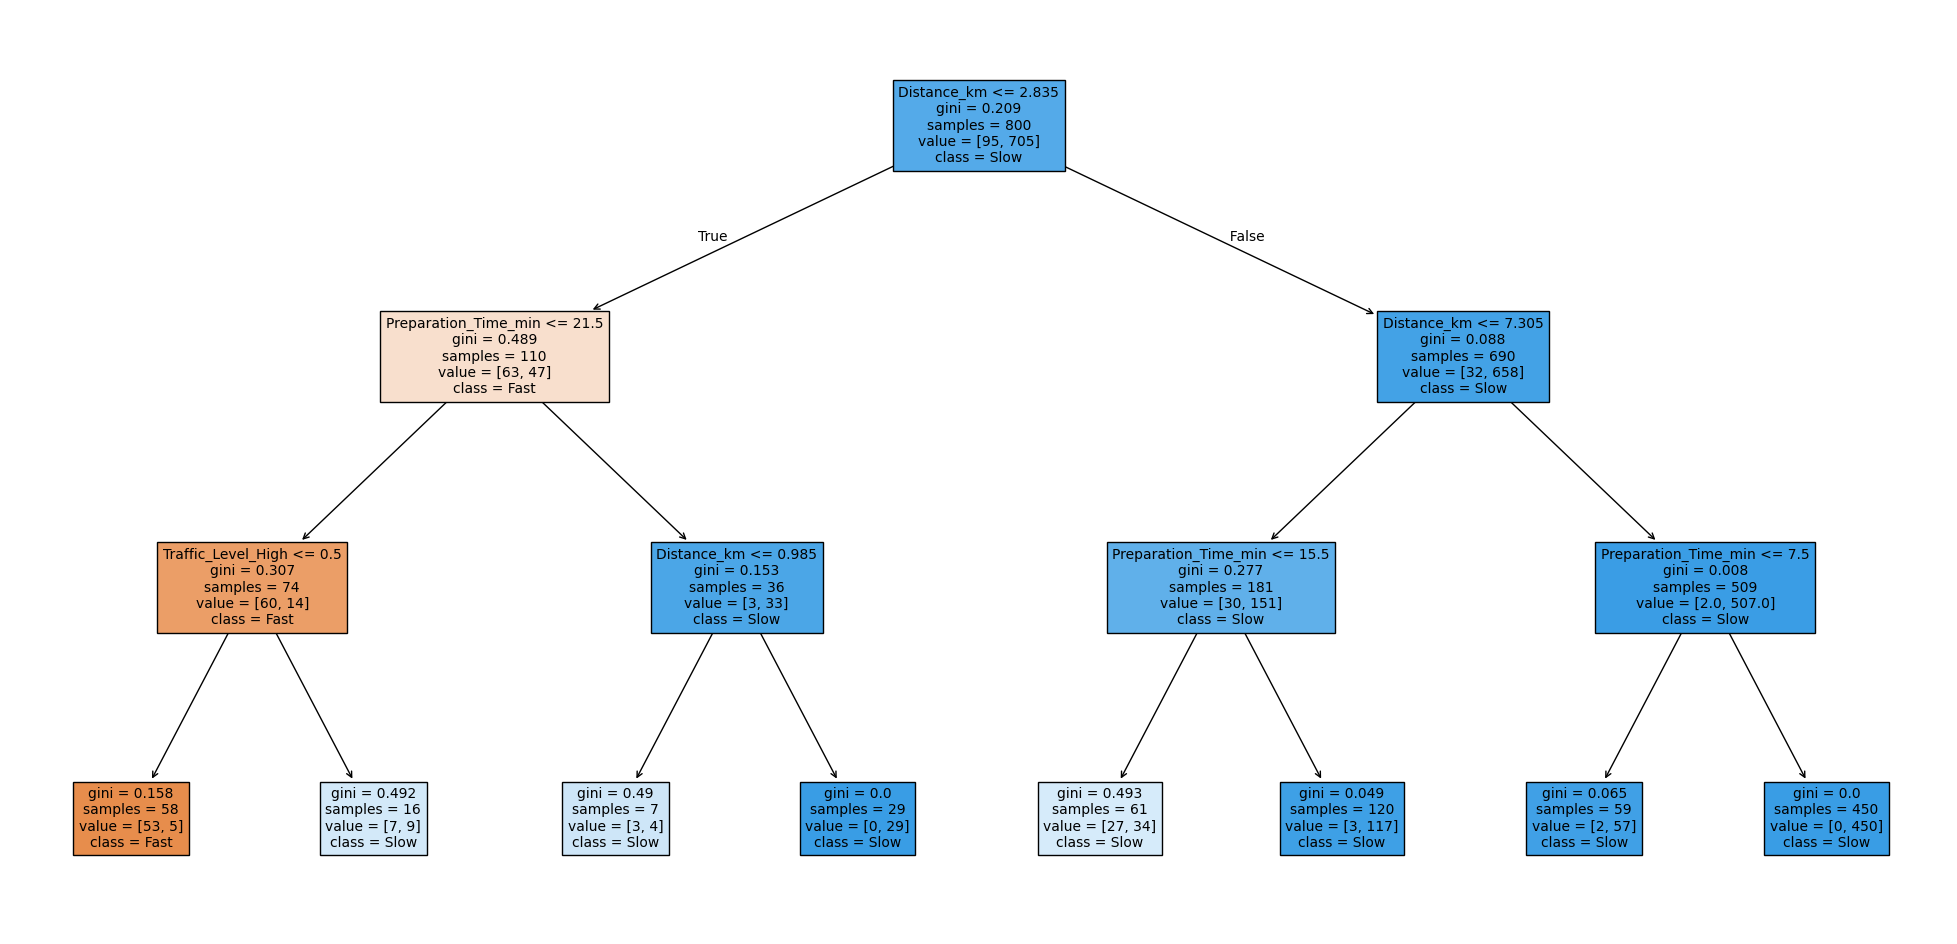

In [54]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

df["Delivery_Class"] = np.where(df["Delivery_Time_min"] <= 30, "Fast", "Slow")


X = df[[
    "Distance_km",
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
]]

y = df["Delivery_Class"]


categorical_features = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]
numerical_features = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs"
]


preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep numerical features as they are
)


X_processed = preprocessor.fit_transform(X)



cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = list(cat_feature_names) + numerical_features


X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)


model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train,y_train)


print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))


plt.figure(figsize=(25,12))
plot_tree(
    model,
    feature_names=all_feature_names,
    class_names=model.classes_,
    filled=True,
    fontsize=10
)
plt.show()

### Interpretation of the First Three Splits

1. The tree first checks the **Delivery Person Rating** because highly rated delivery agents are likely to complete deliveries faster.

2. Next, it checks **Multiple Deliveries** since handling more than one order at a time can increase delivery time.

3. Finally, it checks **Vehicle Condition** because vehicles in better condition may help reduce delays and improve delivery speed.

These splits help the decision tree classify deliveries as **Fast** or **Slow** based on factors that directly affect delivery performance.
